# LOFO Inspection -- Data Profiling + Model Validation

Focused, deep inspection of one (group, curve_type, held-out chip) combination, comparing
`cnn_gru_dual_attn_recon` baseline against its `supcon3` / `dann` / `coral` / `pc_recenter`
variants -- the shift-correction techniques discussed for the domain-shift problem.

**Part 1 -- Data profiling** (no model involved):
1. Sample counts per chip x label
2. Curve-space t-SNE (colored by label, colored by chip)
3. Per-label mean curves across chips (reused from `20260813-pc_ttp_alignment_validation.ipynb`)
4. Intra/inter-chip curve similarity (reused from
   `20260817-intra_inter_chip_curve_similarity.ipynb` sections 5-6)
5. Target-pair curve distance matrix -- a "confusion matrix" computed from the raw curves
   instead of model predictions, for comparing against Part 2's real confusion matrices

**Part 2 -- Model validation** (one saved LOFO model per variant):
1. Confusion matrices + majority-class bias check
2. Embedding-space t-SNE (train=dot, held-out chip=x; colored by label / by chip)
3. Train-vs-held-out embedding distance: MMD (RBF), Wasserstein, silhouette
4. Prediction-confidence histograms (correct vs incorrect)

Config below is fixed to `final_4_chip_clean_nn` | `ori_curve_sg_p4_norm` | `pc_ttp`/`min` |
`noamp_remove`. `SELECTED_HELD_OUTS` currently covers only `DDM_01_06` -- extend the list to
the other chips once this is validated (everything below loops over it, nothing is hardcoded
to one chip).

In [1]:
import os, sys, importlib, colorsys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, cdist, squareform
from scipy.stats import wasserstein_distance_nd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, confusion_matrix as sk_cm
import umap

try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(os.path.dirname(os.path.dirname(notebook_path)))
except Exception as e:
    print(f"Could not change directory: {e}")

print("CWD:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config

# Import-only -- none of these .py files are modified.
cdt = importlib.import_module("04_cross_dataset_training")
p08 = importlib.import_module("08_cross_dataset_predict_new_chip")
vis07 = importlib.import_module("07_attribution_vis_all")
rio = importlib.import_module("cross_dataset_result_io")

import tensorflow as tf
# DANN/CORAL models were compiled without jit_compile=False -- XLA's cudnn autotuner can
# spuriously RESOURCE_EXHAUST even on an idle GPU (see 20260814-pc_recenter_combo_sweep.ipynb).
tf.config.optimizer.set_jit(False)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.3, 'font.size': 9})
print("Imports OK.")

2026-08-27 09:34:37.347297: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-27 09:34:37.369562: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-27 09:34:37.369600: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-27 09:34:37.385163: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-27 09:34:43.191867: W tensorflow/compiler/tf

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main


2026-08-27 09:35:06.920341: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-27 09:35:06.975321: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-27 09:35:06.975752: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

Imports OK.


## 1. Configuration

In [2]:
GROUP_NAME        = "final_6_chip_clean_nn"
EXP_FOLDER        = config.FINAL_EXP_FOLDER
CURVE_TYPE        = "ori_curve_sg_p4_norm"
CURVE_ALIGNMENT   = "pc_ttp"
PC_TTP_ANCHOR     = "min"
TRAIN_CENTER_FRAC = None
OUTLIER_FILTER    = "noamp_remove"
MODE_STR          = "lofo"

MODELS = ["cnn_gru_dual_attn_recon", "cnn_gru_dual_attn_recon_supcon", "cnn_gru_dual_attn_recon_supcon3",
          "cnn_gru_dual_attn_recon_dann", "cnn_gru_dual_attn_recon_coral"]
PC_RECENTER_BASE = "cnn_gru_dual_attn_recon"
PC_RECENTER_TAG  = f"{PC_RECENTER_BASE}_pc_recenter"
ALL_MODEL_TAGS   = MODELS + [PC_RECENTER_TAG]

# Standard model naming -- kept identical to 0_final_result_comparison.ipynb's FAMILY_LABELS,
# the single source of truth for how a model key is displayed on any chart in either notebook.
FAMILY_LABELS = {
    'cnn_gru_dual': 'CNN-BiGRU',
    'cnn_gru_dual_dann': 'CNN-BiGRU\n+ DANN',
    'cnn_gru_dual_coral': 'CNN-BiGRU\n+ CORAL',
    'cnn_gru_dual_supcon': 'CNN-BiGRU\n+ Contrastive Loss (SC1)',
    'cnn_gru_dual_supcon3': 'CNN-BiGRU\n+ Contrastive Loss',
    'cnn_gru_dual_pc_recenter': 'CNN-BiGRU\n+ Latent Alignment',

    'cnn_gru_dual_attn_recon':   'CNN-BiGRU + Spatial Attn',
    'cnn_gru_dual_attn_recon_dann': 'CNN-BiGRU + Spatial Attn\n+ DANN',
    'cnn_gru_dual_attn_recon_coral': 'CNN-BiGRU + Spatial Attn\n+ CORAL',
    'cnn_gru_dual_attn_recon_supcon': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss (SC1)',
    'cnn_gru_dual_attn_recon_supcon3': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss',
    'cnn_gru_dual_attn_recon_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Latent Alignment',
}

# Should eventually cover every chip in the group -- currently just DDM_01_06 while validating.
SELECTED_HELD_OUTS = ["D20260806_E00_C00_F4500KHz_U_DDM_01_06"]

folder_names = config.CROSS_DATASET_GROUPS[GROUP_NAME]
exp_paths = [Path(EXP_FOLDER, name) for name in folder_names]

def short_name(folder):
    return folder.split('_U_', 1)[1]

out_dir = Path(EXP_FOLDER) / "cross_dataset_cv" / GROUP_NAME / "curve_alignment_pc_ttp" / f"anchor_{PC_TTP_ANCHOR}"
pc_ttp_cache_dir = Path(EXP_FOLDER) / "cross_dataset_cv" / GROUP_NAME / "_cache_pc_ttp"

print(f"Group '{GROUP_NAME}' -> {len(folder_names)} chips:")
for n in folder_names:
    tag = "  <- held-out" if n in SELECTED_HELD_OUTS else ""
    print(f"  - {n} ({short_name(n)}){tag}")

Group 'final_6_chip_clean_nn' -> 6 chips:
  - D20260806_E00_C00_F4500KHz_U_DDM_01_06 (DDM_01_06)  <- held-out
  - D20260807_E00_C00_F4500KHz_U_DDM_02_07 (DDM_02_07)
  - D20260808_E00_C00_F4500KHz_U_DDM_03_01 (DDM_03_01)
  - D20260810_E00_C00_F4500KHz_U_DDM_04_01 (DDM_04_01)
  - D20260825_E00_C00_F4500KHz_U_DDM_05_01 (DDM_05_01)
  - D20260825_E00_C00_F4500KHz_U_DDM_06_02 (DDM_06_02)


# Part 1 -- Data Profiling

## 1.1 Build the PC-TTP-aligned pool (per held-out chip)

In [3]:
def build_pool(held_out_chip):
    """The exact same pool 04_cross_dataset_training.py trains on for this LOFO fold --
    combine_group_pc_aligned() returns ALL chips (held-out included); held_out_chip is only
    used to pick the anchor/common_duration from the *other* chips."""
    return cdt.combine_group_pc_aligned(
        exp_paths, GROUP_NAME, CURVE_TYPE, held_out_chip=held_out_chip,
        anchor_method=PC_TTP_ANCHOR, anchor_pct=cdt.PC_TTP_ANCHOR_PCT_DEFAULT,
        pc_ttp_cache_dir=pc_ttp_cache_dir)

pools = {ho: build_pool(ho) for ho in SELECTED_HELD_OUTS}
print(f"Built {len(pools)} pool(s): {[short_name(h) for h in pools]}")

  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_chip_clean_nn']: dropping 1135 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_chip_clean_nn']: dropping 5523 samples from wells [6, 7, 8, 9] (y_label={6: 'Cov', 7: 'Hadv', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+05', 7: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260807_E00_C00_F4500KHz_U_DDM_02_07
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_chip_clean_nn']: dropping 3570 samples from wells [6, 8, 9] (y_label={6: 'Cov', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260808_E00_C00_F4500KHz_U_DDM_03_01
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_chip_clean_nn']: dropping 1315 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260810_E00_C00_F4500KHz_U_DDM_04_01
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_chip_clean_nn']: dr

## 1.2 Data profile -- sample counts per chip x label

In [4]:
def print_data_profile(combined, held_out_chip):
    df = pd.DataFrame({"chip": [short_name(d) for d in combined["dataset_id"]],
                       "label": combined["Y_mapped"]})
    counts = df.groupby(["chip", "label"]).size().unstack(fill_value=0)
    counts.insert(0, "role", ["held-out" if c == short_name(held_out_chip) else "train"
                              for c in counts.index])
    counts.insert(1, "total", counts.drop(columns="role").sum(axis=1))
    display(counts)
    return counts

for held_out, combined in pools.items():
    print(f"\n=== held_out={short_name(held_out)} ===")
    print_data_profile(combined, held_out)


=== held_out=DDM_01_06 ===


label,role,total,Cov,Hadv,IAV,IBV,Kp
chip,,,,,,,
DDM_01_06,held-out,13372,1848,1919,5777,1907,1921
DDM_02_07,train,9897,0,0,3671,4315,1911
DDM_03_01,train,12956,0,1828,1786,3755,5587
DDM_04_01,train,15259,5641,1943,1920,1921,3834
DDM_05_01,train,15449,3805,5827,1955,1919,1943
DDM_06_02,train,13334,3857,3787,1890,1936,1864


## 1.3 Curve-space t-SNE (colored by label, colored by chip)

In [5]:
def build_label_palette(labels):
    labels = sorted(set(labels) - {"PC"})
    cmap = plt.cm.tab10 if len(labels) <= 10 else plt.cm.tab20
    return {l: cmap(i % cmap.N) for i, l in enumerate(labels)}

def build_chip_palette(chips):
    chips = sorted(set(chips))
    cmap = plt.cm.Set1
    return {c: cmap(i % 9) for i, c in enumerate(chips)}

def _lighten(rgb, amount=0.25):
    """Blend a color toward white -- used for 'train' points in every t-SNE/UMAP scatter
    below, so train vs held-out reads as light-vs-dark shade of the SAME hue/marker instead
    of a different marker shape."""
    r, g, b = rgb[:3]
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount, 1.0)

def _darken(rgb, amount=0.25):
    """Blend a color toward black -- used for 'held-out' points, paired with _lighten()."""
    r, g, b = rgb[:3]
    return (r * (1 - amount), g * (1 - amount), b * (1 - amount), 1.0)

In [6]:
def compute_curve_tsne(combined, held_out_chip, n_sub=3000, seed=0, perplexity=30):
    """The expensive part (t-SNE fit) -- separated from plotting so tweaking marker/color/
    alpha in plot_curve_tsne() below doesn't require recomputing the embedding."""
    curves = np.asarray(combined["curves"])
    y = np.asarray(combined["Y_mapped"])
    chip = np.array([short_name(d) for d in combined["dataset_id"]])
    held_out_short = short_name(held_out_chip)

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(curves), size=min(n_sub, len(curves)), replace=False)
    curves_s, y_s, chip_s = curves[idx], y[idx], chip[idx]
    is_test = chip_s == held_out_short

    emb = TSNE(n_components=2, perplexity=perplexity, random_state=seed, init="pca").fit_transform(curves_s)
    return {"emb": emb, "y": y_s, "chip": chip_s, "is_test": is_test, "held_out_short": held_out_short}

curve_tsne_results = {ho: compute_curve_tsne(combined, ho) for ho, combined in pools.items()}

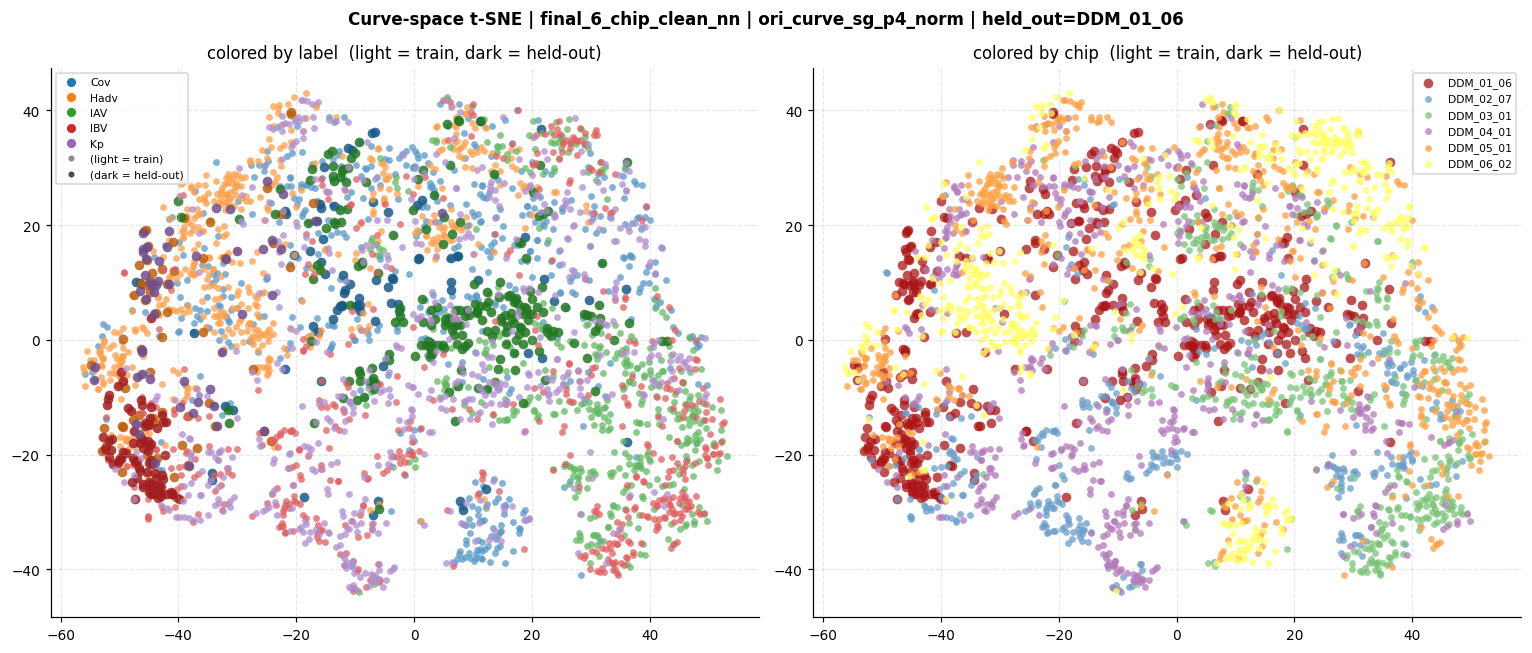

In [7]:
def plot_curve_tsne(tsne_result, figsize=(14, 6)):
    """Draws from an already-computed compute_curve_tsne() result. Train vs held-out is
    encoded as a lighter/darker shade of the same hue and marker (light=train, dark=held-out),
    not by marker shape -- shape alone was too easy to misread at a glance."""
    emb, y_s, chip_s = tsne_result["emb"], tsne_result["y"], tsne_result["chip"]
    is_test, held_out_short = tsne_result["is_test"], tsne_result["held_out_short"]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    label_palette = build_label_palette(y_s)
    for lab, color in label_palette.items():
        m = y_s == lab
        axes[0].scatter(emb[m & ~is_test, 0], emb[m & ~is_test, 1], color=[_lighten(color)], s=20,
                        alpha=0.75, marker='o', linewidths=0)
        axes[0].scatter(emb[m & is_test, 0], emb[m & is_test, 1], color=[_darken(color)], s=40,
                        alpha=0.85, marker='o', linewidths=0)
    if "PC" in set(y_s):
        m = y_s == "PC"
        axes[0].scatter(emb[m & ~is_test, 0], emb[m & ~is_test, 1], color=[_lighten((0.5, 0.5, 0.5))],
                        s=18, alpha=0.75, marker='o', linewidths=0)
        axes[0].scatter(emb[m & is_test, 0], emb[m & is_test, 1], color=[_darken((0.5, 0.5, 0.5))],
                        s=18, alpha=0.75, marker='o', linewidths=0)
        label_palette = {**label_palette, "PC": (0.5, 0.5, 0.5, 1.0)}
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=7, label=l)
              for l, c in label_palette.items()]
    handles += [
        plt.Line2D([0], [0], marker='.', color='w', markerfacecolor=_lighten((0.4, 0.4, 0.4)),
                   markersize=10, label='(light = train)'),
        plt.Line2D([0], [0], marker='.', color='w', markerfacecolor=_darken((0.4, 0.4, 0.4)),
                   markersize=10, label='(dark = held-out)'),
    ]
    axes[0].legend(handles=handles, fontsize=7, loc='best')
    axes[0].set_title("colored by label  (light = train, dark = held-out)")

    chip_palette = build_chip_palette(chip_s)
    for c, color in chip_palette.items():
        m = chip_s == c
        is_ho = c == held_out_short
        shade = _darken(color) if is_ho else _lighten(color)
        axes[1].scatter(emb[m, 0], emb[m, 1], color=[shade], s=(40 if is_ho else 20),
                        alpha=0.75, marker='o', linewidths=0, label=c)
    axes[1].legend(fontsize=7, loc='best')
    axes[1].set_title("colored by chip  (light = train, dark = held-out)")

    fig.suptitle(f"Curve-space t-SNE | {GROUP_NAME} | {CURVE_TYPE} | held_out={held_out_short}",
                fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()


for held_out, tsne_result in curve_tsne_results.items():
    plot_curve_tsne(tsne_result)

## 1.4 Per-label mean curves across chips

Reused (verbatim) from `20260813-pc_ttp_alignment_validation.ipynb`'s `plot_target_across_chips`.

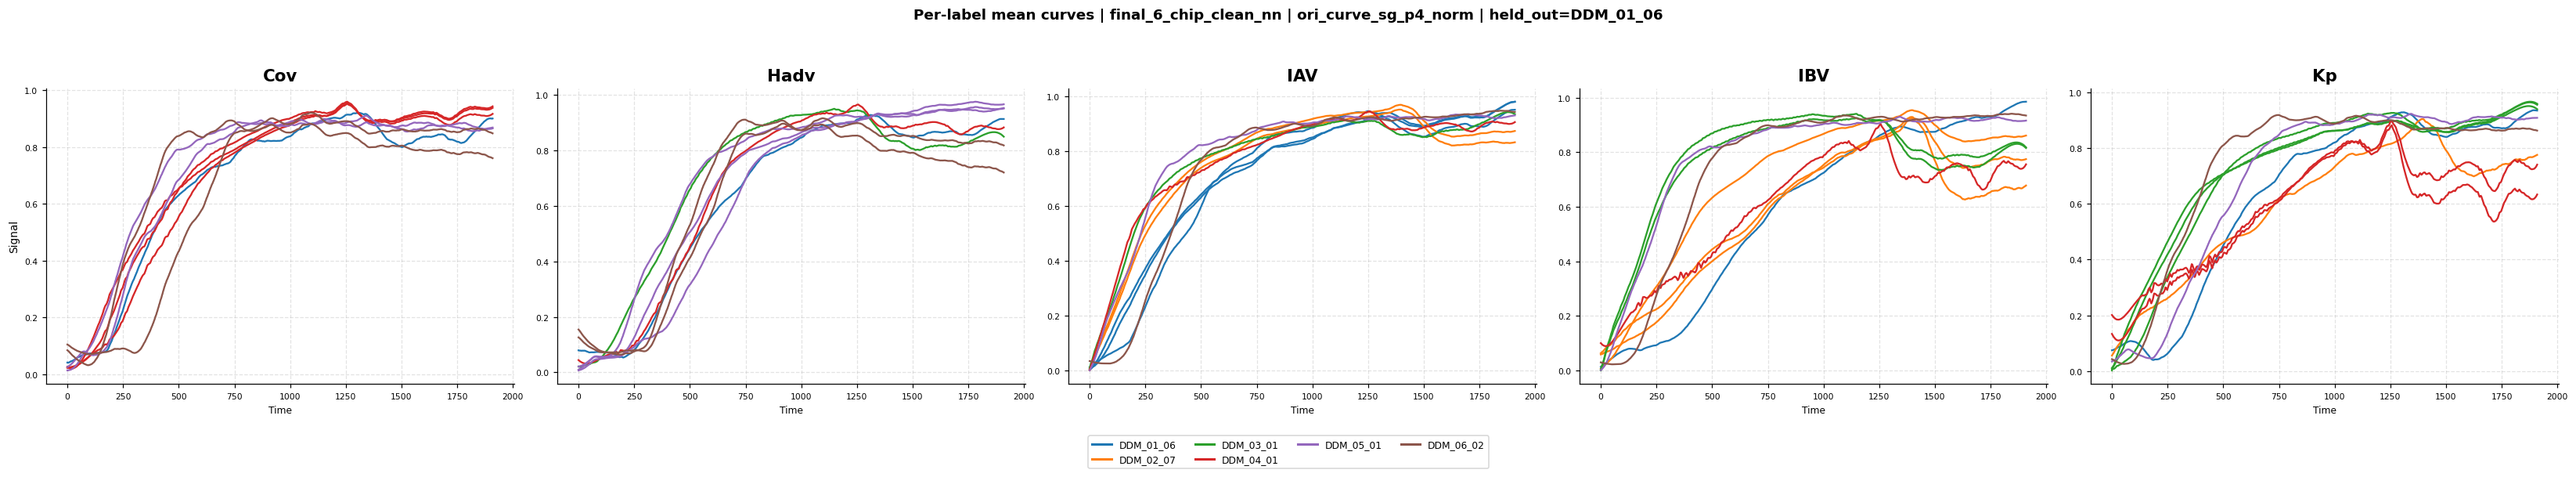

In [8]:
def build_well_table(combined):
    df = pd.DataFrame({
        "well_id": combined["well_ids"],
        "dataset_id": combined["dataset_id"],
        "label": combined["Y_mapped"],
    })
    df["row_idx"] = np.arange(len(df))
    meta = df.groupby("well_id").agg(dataset_id=("dataset_id", "first"), label=("label", "first"))
    row_idx_map = df.groupby("well_id")["row_idx"].apply(np.array)
    wells = meta.join(row_idx_map.rename("row_idx")).reset_index()
    wells["n_pixels"] = wells["row_idx"].apply(len)
    return wells


def _shade(base_rgb, frac, spread=0.3):
    h, l, s = colorsys.rgb_to_hls(*base_rgb[:3])
    l = min(0.85, max(0.15, l + (frac - 0.5) * spread))
    return colorsys.hls_to_rgb(h, l, s)


def _exp_colors(exp_names):
    cmap_exp = plt.cm.tab10
    return {n: cmap_exp(i % 10) for i, n in enumerate(exp_names)}


def _exp_legend(fig, exp_color, exp_names, y_anchor=-0.02):
    handles = [plt.Line2D([0], [0], color=exp_color[n], lw=2, label=short_name(n))
              for n in exp_names]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(exp_names), 4),
              fontsize=8, bbox_to_anchor=(0.5, y_anchor), frameon=True)


def _raw_conc(combined, well_row):
    conc = combined.get("concentration_raw")
    if conc is None:
        return None
    val = conc[well_row["row_idx"][0]]
    try:
        return float(val)
    except (TypeError, ValueError):
        return None


def plot_target_across_chips(combined, label_order=None, figsize_per_cell=(6, 4),
                             title=None, alpha_indiv=0.10, with_all_curves=True,
                             sharey=False, y_scale=None, non_amp_filter=False):
    """Copied from 20260813-pc_ttp_alignment_validation.ipynb / lofo_class_balance_analysis.ipynb
    -- 1 label = 1 plot, mean curve per well, colored by chip."""
    wells = build_well_table(combined)
    exp_names = sorted(wells["dataset_id"].unique())
    exp_color = _exp_colors(exp_names)

    labels_seen = list(dict.fromkeys(wells.sort_values("dataset_id")["label"]))
    if label_order is not None:
        all_labels = [l for l in label_order if l in labels_seen]
        all_labels += [l for l in labels_seen if l not in all_labels]
    else:
        nc    = [l for l in labels_seen if str(l).startswith("NC")]
        nonnc = [l for l in labels_seen if not str(l).startswith("NC")]
        all_labels = sorted(nonnc) + sorted(nc)

    t = np.asarray(combined["resampler"].t_grid, dtype=float)
    n = len(all_labels)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_cell[0] * n, figsize_per_cell[1]*1.35),
                             squeeze=False, sharey="row" if sharey else False)
    axes = axes[0]

    for ax, label in zip(axes, all_labels):
        label_wells = wells[wells["label"] == label].copy()
        label_wells["_conc"] = [_raw_conc(combined, w) for _, w in label_wells.iterrows()]
        concs_sorted = sorted({c for c in label_wells["_conc"] if c is not None})
        n_concs = len(concs_sorted)

        for _, w in label_wells.iterrows():
            idx = w["row_idx"]
            curves = combined["curves"][idx]
            conc = w["_conc"]

            if non_amp_filter:
                keep = curves[:, -1] >= curves[:, 0]
                curves = curves[keep]
                if len(curves) == 0:
                    continue

            mean = curves.mean(axis=0)
            frac = (concs_sorted.index(conc) / (n_concs - 1)) if (conc is not None and n_concs > 1) else 0.5
            # color = _shade(exp_color[w["dataset_id"]], 1 - frac)
            color = _shade(exp_color[w["dataset_id"]], 0.5)

            if with_all_curves:
                step = max(1, len(curves) // 30)
                for c in curves[::step]:
                    ax.plot(t, c, color=color, lw=0.4, alpha=alpha_indiv, rasterized=True)
            ax.plot(t, mean, color=color, lw=1.5)

        ax.set_title(str(label), fontsize=14, fontweight="bold")
        ax.set_xlabel("Time", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.tick_params(labelsize=7)
        if y_scale is not None:
            ax.set_ylim(*y_scale)

    axes[0].set_ylabel("Signal", fontsize=9)
    fig.suptitle(title or "Same target across chips  (colour=chip, shade=concentration)",
                fontsize=12, fontweight="bold")
    _exp_legend(fig, exp_color, exp_names)
    plt.tight_layout(rect=[0, 0.08, 1, 0.93])
    plt.show()


for held_out, combined in pools.items():
    plot_target_across_chips(
        combined,
        title=f"Per-label mean curves | {GROUP_NAME} | {CURVE_TYPE} | held_out={short_name(held_out)}",
        with_all_curves=False,
    )

In [9]:
def _label_colors(labels):
    cmap_lbl = plt.cm.tab10
    return {l: cmap_lbl(i % 10) for i, l in enumerate(labels)}


def _label_legend(fig, label_color, labels, y_anchor=-0.02):
    handles = [plt.Line2D([0], [0], color=label_color[l], lw=2, label=str(l))
              for l in labels]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(labels), 4),
              fontsize=8, bbox_to_anchor=(0.5, y_anchor), frameon=True)


def plot_chip_across_targets(combined, label_order=None, figsize_per_cell=(6, 4),
                             title=None, alpha_indiv=0.10, with_all_curves=True,
                             sharey=False, y_scale=None, non_amp_filter=False):
    """Mirrors plot_target_across_chips with the subplot axis and colour-by axis
    swapped -- 1 chip = 1 plot, mean curve per well, colored by target."""
    wells = build_well_table(combined)
    exp_names = sorted(wells["dataset_id"].unique())

    labels_seen = list(dict.fromkeys(wells.sort_values("dataset_id")["label"]))
    if label_order is not None:
        all_labels = [l for l in label_order if l in labels_seen]
        all_labels += [l for l in labels_seen if l not in all_labels]
    else:
        nc    = [l for l in labels_seen if str(l).startswith("NC")]
        nonnc = [l for l in labels_seen if not str(l).startswith("NC")]
        all_labels = sorted(nonnc) + sorted(nc)
    label_color = _label_colors(all_labels)

    t = np.asarray(combined["resampler"].t_grid, dtype=float)
    n = len(exp_names)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_cell[0] * n, figsize_per_cell[1]*1.35),
                             squeeze=False, sharey="row" if sharey else False)
    axes = axes[0]

    for ax, exp_name in zip(axes, exp_names):
        exp_wells = wells[wells["dataset_id"] == exp_name]

        for _, w in exp_wells.iterrows():
            idx = w["row_idx"]
            curves = combined["curves"][idx]

            if non_amp_filter:
                keep = curves[:, -1] >= curves[:, 0]
                curves = curves[keep]
                if len(curves) == 0:
                    continue

            mean = curves.mean(axis=0)
            color = _shade(label_color[w["label"]], 0.5)

            if with_all_curves:
                step = max(1, len(curves) // 30)
                for c in curves[::step]:
                    ax.plot(t, c, color=color, lw=0.4, alpha=alpha_indiv, rasterized=True)
            ax.plot(t, mean, color=color, lw=1.5)

        ax.set_title(short_name(exp_name), fontsize=14, fontweight="bold")
        ax.set_xlabel("Time", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.tick_params(labelsize=7)
        if y_scale is not None:
            ax.set_ylim(*y_scale)

    axes[0].set_ylabel("Signal", fontsize=9)
    fig.suptitle(title or "Same chip across targets  (colour=target)",
                fontsize=12, fontweight="bold")
    _label_legend(fig, label_color, all_labels)
    plt.tight_layout(rect=[0, 0.08, 1, 0.93])
    plt.show()


In [10]:
def load_pc_pool_pc_ttp(exp_paths, curve_type, combined):
    """Same idea as load_pc_pool (1.4b), but for a PC-TTP-aligned `combined`
    pool (built via cdt.combine_group_pc_aligned): each chip's PC curves get
    the identical shift_to_pc_ttp_anchor + truncate_to_common_duration
    treatment as the main curves -- mirrors 08_cross_dataset_predict_new_chip.py's
    align_new_chip (lines 109-124) -- using the anchor/common_duration/
    pc_ttp_per_chip already stored in combined['pc_ttp_recipe'], so PC lands
    on the same (shifted+truncated) time axis as everything else in this pool."""
    recipe = combined["pc_ttp_recipe"]
    resampler = combined["resampler"]
    curves_parts, dataset_id_parts, well_id_parts = [], [], []
    for exp_path in exp_paths:
        pc = cdt.load_pc_wells_snapshot(exp_path, curve_type)
        if pc is None:
            continue
        ttp = recipe["pc_ttp_per_chip"].get(exp_path.name)
        pc_t, pc_c, _ = cdt.shift_to_pc_ttp_anchor(pc["timestamps"], pc["curves"], ttp, recipe["anchor"])
        pc_t, pc_c = cdt.truncate_to_common_duration(pc_t, pc_c, recipe["common_duration"])
        curves_resampled = resampler.transform(pc_t, pc_c)
        if curve_type.endswith("_norm"):
            curves_resampled = cdt.normalize_curves_minmax(curves_resampled)
        n = len(curves_resampled)
        curves_parts.append(curves_resampled)
        dataset_id_parts.append(np.full(n, exp_path.name, dtype=object))
        well_id_parts.append(np.full(n, f"{exp_path.name}_PC", dtype=object))
    if not curves_parts:
        return None
    n_total = sum(len(c) for c in curves_parts)
    return {
        "curves": np.concatenate(curves_parts, axis=0),
        "dataset_id": np.concatenate(dataset_id_parts, axis=0),
        "well_ids": np.concatenate(well_id_parts, axis=0),
        "Y_mapped": np.full(n_total, "PC", dtype=object),
        "concentration_raw": np.full(n_total, None, dtype=object),
    }


def with_pc_added_pc_ttp(combined, exp_paths, curve_type):
    pc_pool = load_pc_pool_pc_ttp(exp_paths, curve_type, combined)
    if pc_pool is None:
        print("  [!] No PC snapshot found for any chip (--drop_pc not used?).")
        return combined
    merged = dict(combined)
    for key in ["curves", "dataset_id", "well_ids", "Y_mapped", "concentration_raw"]:
        merged[key] = np.concatenate([combined[key], pc_pool[key]], axis=0)
    return merged

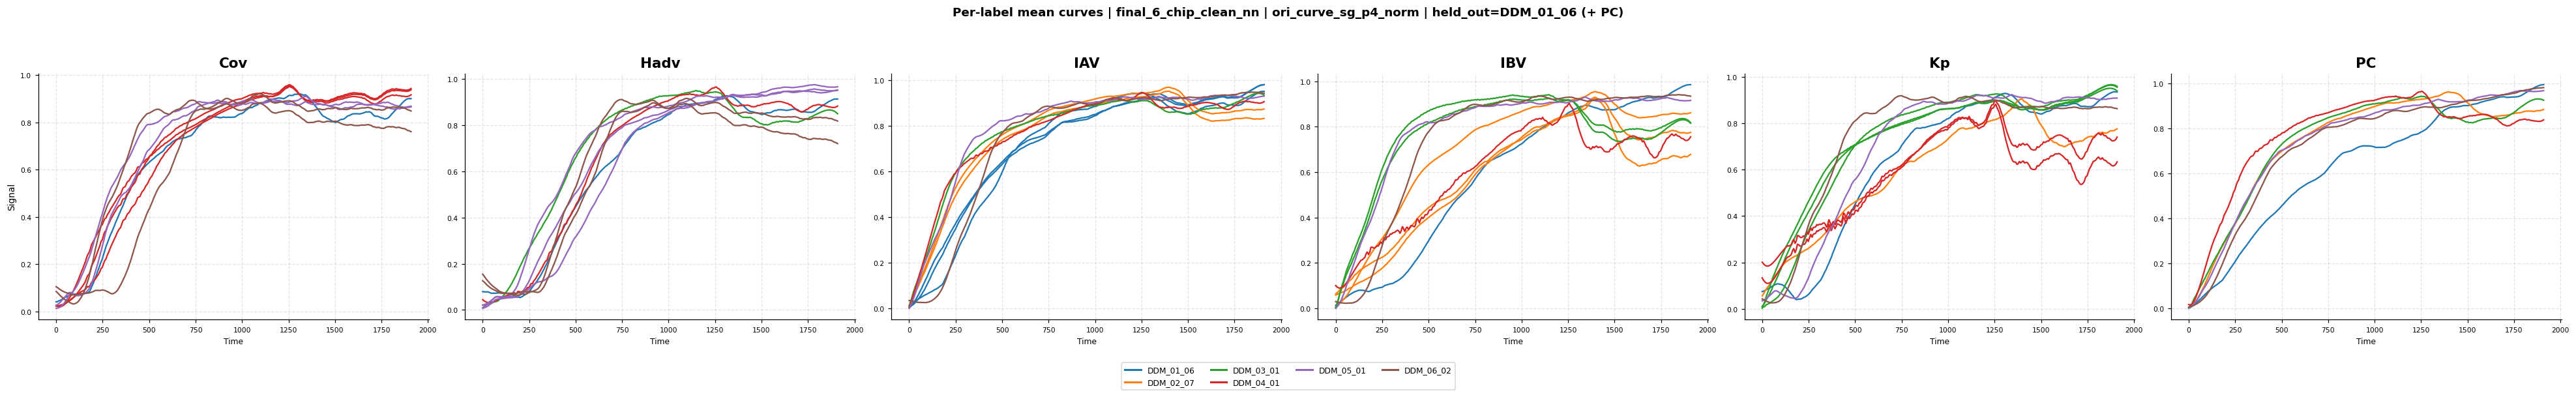

In [11]:
for held_out, combined in pools.items():
    plot_target_across_chips(
        with_pc_added_pc_ttp(combined, exp_paths, CURVE_TYPE),
        title=f"Per-label mean curves | {GROUP_NAME} | {CURVE_TYPE} | held_out={short_name(held_out)} (+ PC)",
        with_all_curves=False,
    )

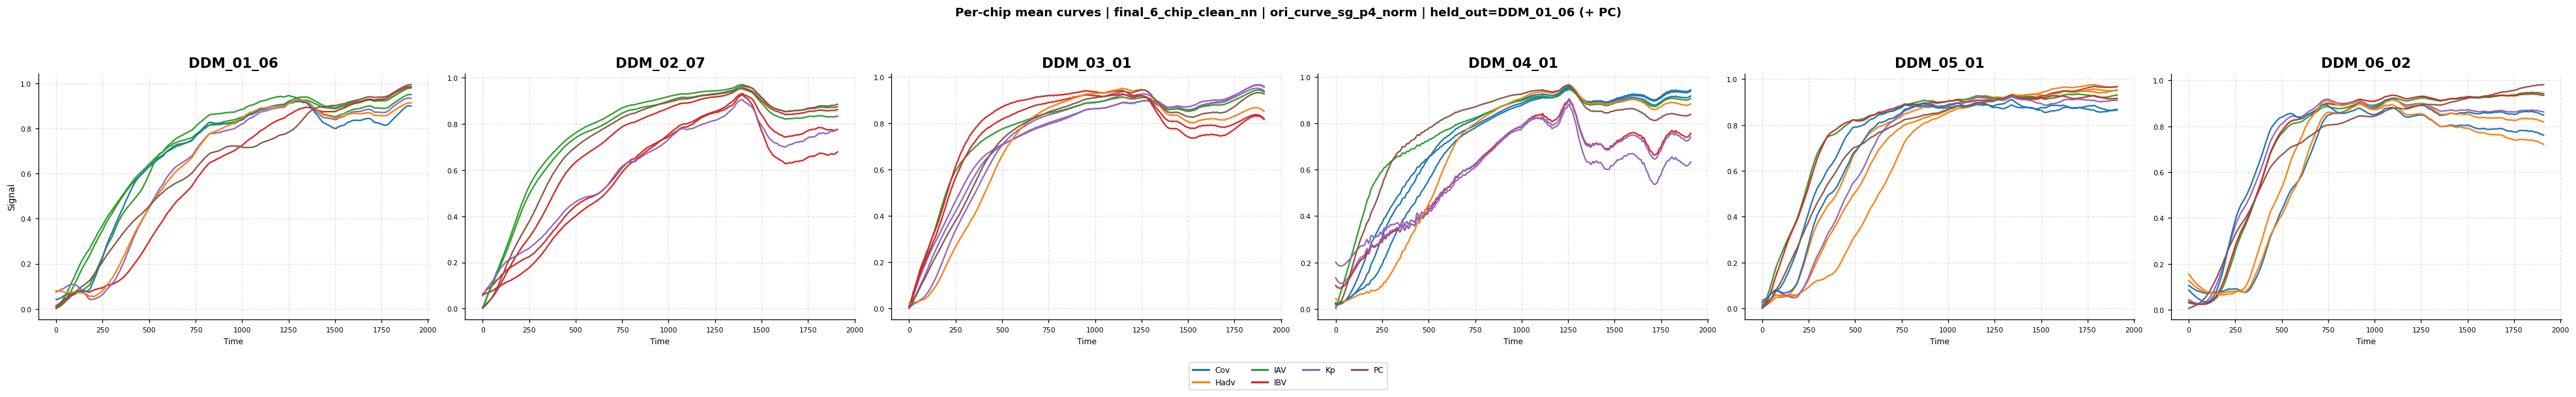

In [12]:
for held_out, combined in pools.items():
    plot_chip_across_targets(
        with_pc_added_pc_ttp(combined, exp_paths, CURVE_TYPE),
        title=f"Per-chip mean curves | {GROUP_NAME} | {CURVE_TYPE} | held_out={short_name(held_out)} (+ PC)",
        with_all_curves=False,
    )


## 1.4b Per-label mean curves across chips -- acquisition_start alignment (+ PC)

Same plot as 1.4, but built from `combine_group` (plain acquisition_start
alignment -- curves resampled onto a common grid with no PC-TTP shift/truncation)
instead of `combine_group_pc_aligned`. Also adds a synthetic `"PC"` panel: the
positive-control curves dropped from training via `01`'s `--drop_pc` (stored in
`curve_for_training.joblib`'s `pc_wells` snapshot), resampled onto the same grid and
concatenated in as one well per chip so the existing `plot_target_across_chips` needs
no changes.

  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_chip_clean_nn']: dropping 1135 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_chip_clean_nn']: dropping 5523 samples from wells [6, 7, 8, 9] (y_label={6: 'Cov', 7: 'Hadv', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+05', 7: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260807_E00_C00_F4500KHz_U_DDM_02_07
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_chip_clean_nn']: dropping 3570 samples from wells [6, 8, 9] (y_label={6: 'Cov', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260808_E00_C00_F4500KHz_U_DDM_03_01
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_chip_clean_nn']: dropping 1315 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260810_E00_C00_F4500KHz_U_DDM_04_01
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_chip_clean_nn']: dr

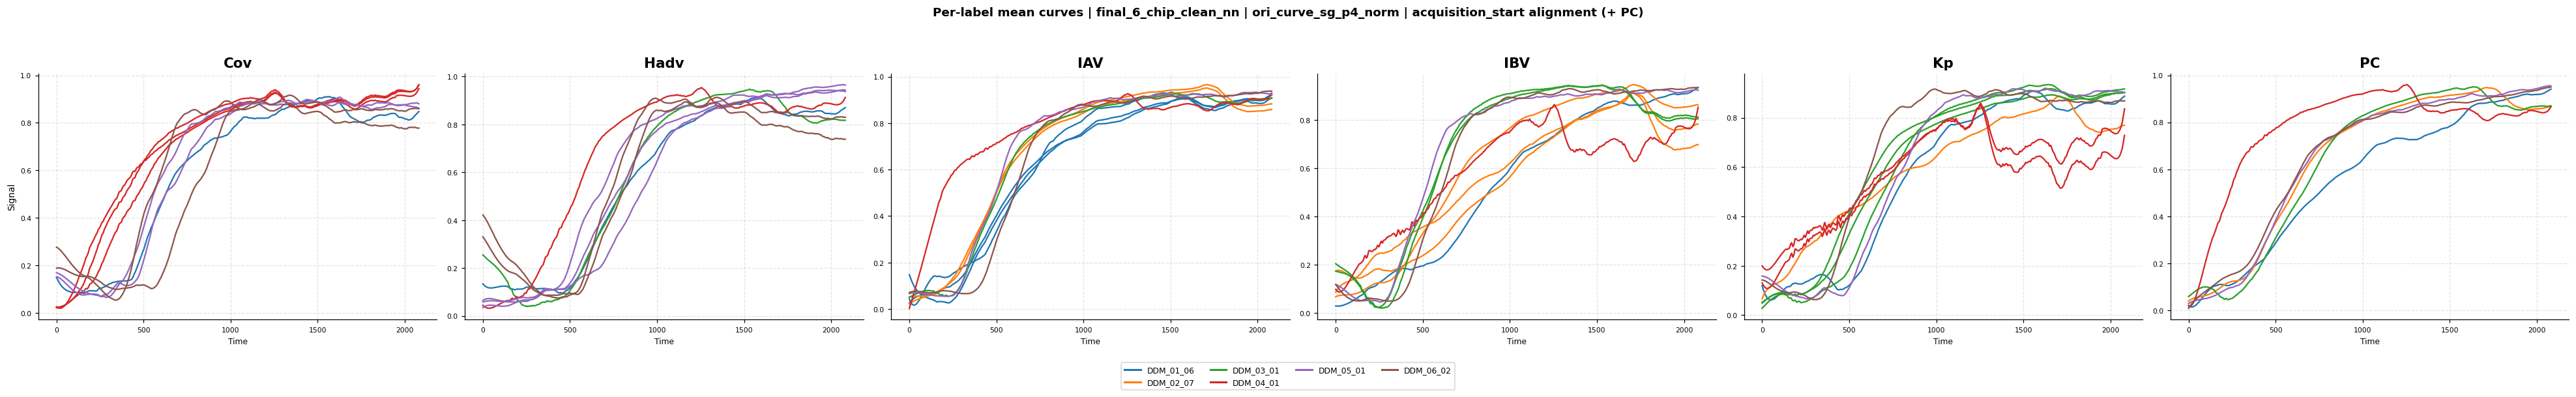

In [ ]:
def load_pc_pool(exp_paths, curve_type, resampler):
    """Loads each chip's dropped PC curves (01's --drop_pc snapshot, via
    cdt.load_pc_wells_snapshot) and resamples them onto `resampler`'s common
    grid -- so PC can be concatenated in as an ordinary 'PC' well per chip and
    rendered by the existing plot_target_across_chips unmodified."""
    curves_parts, dataset_id_parts, well_id_parts = [], [], []
    for exp_path in exp_paths:
        pc = cdt.load_pc_wells_snapshot(exp_path, curve_type)
        if pc is None:
            continue
        t_zeroed = pc["timestamps"] - pc["timestamps"][0]
        curves_resampled = resampler.transform(t_zeroed, pc["curves"])
        n = len(curves_resampled)
        curves_parts.append(curves_resampled)
        dataset_id_parts.append(np.full(n, exp_path.name, dtype=object))
        well_id_parts.append(np.full(n, f"{exp_path.name}_PC", dtype=object))
    if not curves_parts:
        return None
    n_total = sum(len(c) for c in curves_parts)
    return {
        "curves": np.concatenate(curves_parts, axis=0),
        "dataset_id": np.concatenate(dataset_id_parts, axis=0),
        "well_ids": np.concatenate(well_id_parts, axis=0),
        "Y_mapped": np.full(n_total, "PC", dtype=object),
        "concentration_raw": np.full(n_total, None, dtype=object),
    }


def with_pc_added(combined, exp_paths, curve_type):
    pc_pool = load_pc_pool(exp_paths, curve_type, combined["resampler"])
    if pc_pool is None:
        print("  [!] No PC snapshot found for any chip (--drop_pc not used?).")
        return combined
    merged = dict(combined)
    for key in ["curves", "dataset_id", "well_ids", "Y_mapped", "concentration_raw"]:
        merged[key] = np.concatenate([combined[key], pc_pool[key]], axis=0)
    return merged


combined_acq = cdt.combine_group(exp_paths, GROUP_NAME, CURVE_TYPE)
combined_acq_pc = with_pc_added(combined_acq, exp_paths, CURVE_TYPE)

plot_target_across_chips(
    combined_acq_pc,
    title=f"Per-label mean curves | {GROUP_NAME} | {CURVE_TYPE} | acquisition_start alignment (+ PC)",
    with_all_curves=False,
)

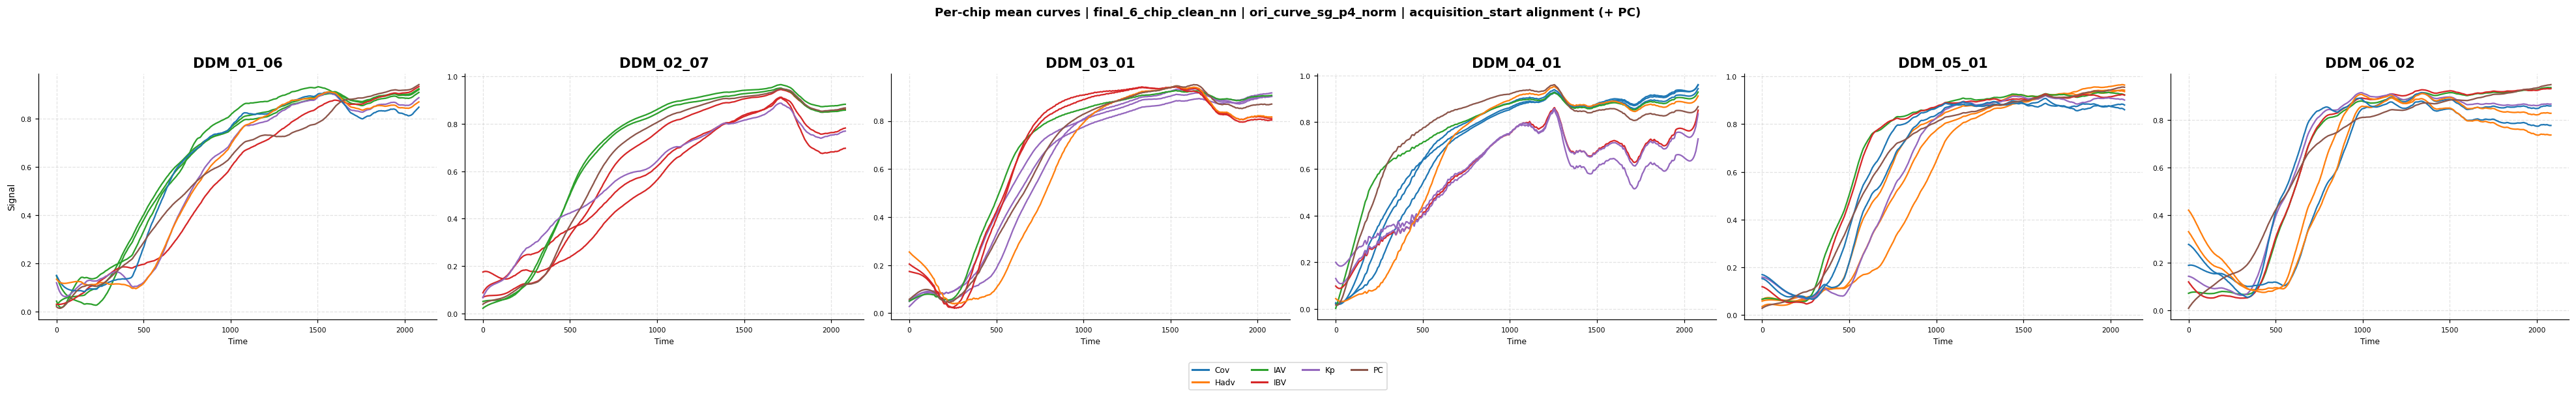

In [14]:
plot_chip_across_targets(
    combined_acq_pc,
    title=f"Per-chip mean curves | {GROUP_NAME} | {CURVE_TYPE} | acquisition_start alignment (+ PC)",
    with_all_curves=False,
)


## 1.5 Intra/inter-chip curve similarity

Reused from `20260817-intra_inter_chip_curve_similarity.ipynb` sections 5-6 (distance decomposition + silhouette).

In [15]:
def combined_to_pool(combined):
    """Adapts combine_group_pc_aligned()'s dict to the {curves, y_mapped, dataset_id,
    well_ids} shape compute_distance_summary/compute_silhouette_summary expect (PC excluded --
    it's a reference well, not a classification target)."""
    y_mapped = np.asarray(combined["Y_mapped"])
    dataset_id = np.array([short_name(d) for d in combined["dataset_id"]])
    well_ids_raw = combined.get("well_ids")
    well_ids = (np.array([str(w).split("::", 1)[-1] for w in well_ids_raw])
               if well_ids_raw is not None else None)
    mask = y_mapped != "PC"
    return {"curves": combined["curves"][mask], "y_mapped": y_mapped[mask],
           "dataset_id": dataset_id[mask], "well_ids": well_ids[mask] if well_ids is not None else None}


def _sub_idx(idx_pool, n_max, rng):
    idx_pool = np.asarray(idx_pool)
    if len(idx_pool) <= n_max:
        return idx_pool
    return rng.choice(idx_pool, size=n_max, replace=False)


def _mean_pairwise_dist(mat):
    if len(mat) < 2:
        return np.nan
    return pdist(mat).mean()


def _groupby_idx(keys_iter):
    groups = {}
    for i, k in enumerate(keys_iter):
        groups.setdefault(k, []).append(i)
    return groups.items()


def compute_distance_summary(group_name, pool, n_sub=150, seed=0):
    curves, y_mapped, dataset_id, well_ids = pool["curves"], pool["y_mapped"], pool["dataset_id"], pool["well_ids"]
    rng = np.random.default_rng(seed)

    intra_well = []
    if well_ids is not None:
        for (chip, w), idx in _groupby_idx(zip(dataset_id, well_ids)):
            idx_sub = _sub_idx(idx, n_sub, rng)
            d = _mean_pairwise_dist(curves[idx_sub])
            if not np.isnan(d):
                intra_well.append(d)
    lvl1 = np.nanmean(intra_well) if intra_well else np.nan

    inter_well_same_label = []
    if well_ids is not None:
        for (chip, lab), idx in _groupby_idx(zip(dataset_id, y_mapped)):
            idx = np.asarray(idx)
            wells_here = np.unique(well_ids[idx])
            if len(wells_here) < 2:
                continue
            well_means = np.stack([curves[idx[well_ids[idx] == w]].mean(axis=0) for w in wells_here])
            inter_well_same_label.append(_mean_pairwise_dist(well_means))
    lvl2 = np.nanmean(inter_well_same_label) if inter_well_same_label else np.nan

    inter_chip_same_label = []
    for lab in sorted(set(y_mapped)):
        idx = np.where(y_mapped == lab)[0]
        chips_here = np.unique(dataset_id[idx])
        if len(chips_here) < 2:
            continue
        chip_means = np.stack([curves[idx[dataset_id[idx] == c]].mean(axis=0) for c in chips_here])
        inter_chip_same_label.append(_mean_pairwise_dist(chip_means))
    lvl3 = np.nanmean(inter_chip_same_label) if inter_chip_same_label else np.nan

    labels = sorted(set(y_mapped))
    label_means = np.stack([curves[y_mapped == lab].mean(axis=0) for lab in labels])
    lvl4 = _mean_pairwise_dist(label_means) if len(labels) >= 2 else np.nan

    def _ratio(a, b):
        return a / b if (b is not None and not np.isnan(b) and b > 0) else np.nan

    return pd.DataFrame([{
        "group": group_name,
        "intra_well_pixel": lvl1,
        "inter_well_same_chip_same_label": lvl2,
        "inter_chip_same_label": lvl3,
        "inter_label_pooled": lvl4,
        "chip_vs_well_ratio": _ratio(lvl3, lvl2),
        "chip_vs_pixel_ratio": _ratio(lvl3, lvl1),
        "label_vs_chip_ratio": _ratio(lvl4, lvl3),
    }])


def compute_silhouette_summary(group_name, pool, n_components=20, n_sub=300, seed=0):
    curves, y_mapped, dataset_id, well_ids = pool["curves"], pool["y_mapped"], pool["dataset_id"], pool["well_ids"]
    rng = np.random.default_rng(seed)

    n_comp = max(2, min(n_components, curves.shape[1], curves.shape[0] - 1))
    pca = PCA(n_components=n_comp, random_state=seed).fit(curves)
    evr = pca.explained_variance_ratio_.sum()

    def _sil(mask, group_arr):
        idx = np.where(mask)[0]
        idx_sub = _sub_idx(idx, n_sub, rng)
        labels_sub = group_arr[idx_sub]
        if len(set(labels_sub)) < 2:
            return np.nan
        X = pca.transform(curves[idx_sub])
        return silhouette_score(X, labels_sub)

    sil_by_well = []
    if well_ids is not None:
        for chip in sorted(set(dataset_id)):
            s = _sil(dataset_id == chip, well_ids)
            if not np.isnan(s):
                sil_by_well.append(s)
    sil_by_well_mean = np.nanmean(sil_by_well) if sil_by_well else np.nan

    sil_by_chip = []
    for lab in sorted(set(y_mapped)):
        s = _sil(y_mapped == lab, dataset_id)
        if not np.isnan(s):
            sil_by_chip.append(s)
    sil_by_chip_mean = np.nanmean(sil_by_chip) if sil_by_chip else np.nan

    sil_by_label = _sil(np.ones(len(y_mapped), dtype=bool), y_mapped)

    return pd.DataFrame([{
        "group": group_name, "pca_components": n_comp, "pca_explained_var": evr,
        "silhouette_by_well_within_chip": sil_by_well_mean,
        "silhouette_by_chip_within_label": sil_by_chip_mean,
        "silhouette_by_label_pooled": sil_by_label,
    }])


print("Curve-similarity functions defined.")

Curve-similarity functions defined.


In [16]:
distance_rows, silhouette_rows = [], []
for held_out, combined in pools.items():
    pool = combined_to_pool(combined)
    tag = f"{GROUP_NAME}|{short_name(held_out)}"
    distance_rows.append(compute_distance_summary(tag, pool))
    silhouette_rows.append(compute_silhouette_summary(tag, pool))

distance_summary_df = pd.concat(distance_rows, ignore_index=True)
silhouette_summary_df = pd.concat(silhouette_rows, ignore_index=True)
display(distance_summary_df)
display(silhouette_summary_df)

,group,intra_well_pixel,inter_well_same_chip_same_label,inter_chip_same_label,inter_label_pooled,chip_vs_well_ratio,chip_vs_pixel_ratio,label_vs_chip_ratio
0,final_6_chip_clean_nn|DDM_01_06,3.001646,1.951121,2.990334,2.001555,1.532624,0.996231,0.669342


,group,pca_components,pca_explained_var,silhouette_by_well_within_chip,silhouette_by_chip_within_label,silhouette_by_label_pooled
0,final_6_chip_clean_nn|DDM_01_06,20,0.988313,-0.005986,0.025669,-0.077275


## 1.6 Held-out vs. training curve distance ("confusion matrix" shape, but from data, not predictions)

Same layout as a real confusion matrix (rows = held-out chip's label, columns = training
chips' label), but each cell is Euclidean distance between **well-mean curves**, comparing
only the **held-out chip's** wells against the **training chips'** wells -- never held-out vs.
held-out or training vs. training. This is the raw-curve analogue of section 2.4's train-vs-
held-out embedding distance (MMD/Wasserstein/silhouette), but decomposed per target instead
of pooled across all targets, and computed straight from the data with no model involved.
Diagonal cells (e.g. held-out's Cov vs training's Cov) are the direct "does this target's
curve shift between chips" signal; off-diagonal cells show whether the held-out chip's target
X looks more like training's target Y than like training's own X.

**Metric -- Euclidean, deliberately, not DTW**: DTW's main advantage over Euclidean is
tolerance to time misalignment, but these curves are already PC-TTP time-aligned (that's the
entire point of that step), so the failure mode DTW fixes has already been corrected
upstream. Euclidean also matches section 1.5 (`pdist`'s default there too), so the two
sections' numbers stay on the same scale. `metric='correlation'` (1 - Pearson r, shape-only,
blind to residual amplitude/offset) is available below as a switchable alternative.

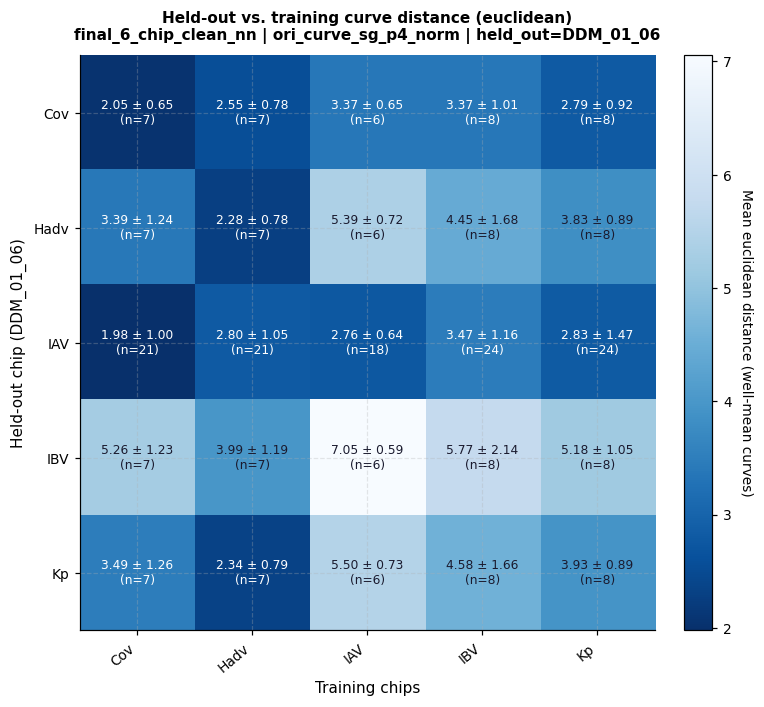

In [17]:
def compute_label_pair_distance_matrix(combined, held_out_chip, metric='euclidean'):
    """Distance between the HELD-OUT chip's well-mean curves and the TRAINING chips'
    well-mean curves (PC excluded -- a reference well, not a classification target), grouped
    by (held_out_label, train_label). Held-out wells and training wells are always disjoint
    sets, so every cell is a genuine cross-set comparison -- no self-pairs to worry about."""
    wells = build_well_table(combined)
    wells = wells[wells["label"] != "PC"].reset_index(drop=True)
    well_curves = np.stack([combined["curves"][idx].mean(axis=0) for idx in wells["row_idx"]])
    well_labels = wells["label"].to_numpy()
    is_held_out = wells["dataset_id"].to_numpy() == held_out_chip

    test_curves, test_labels = well_curves[is_held_out], well_labels[is_held_out]
    train_curves, train_labels = well_curves[~is_held_out], well_labels[~is_held_out]

    row_labels = sorted(set(test_labels))
    col_labels = sorted(set(train_labels))
    mean_mat = np.full((len(row_labels), len(col_labels)), np.nan)
    std_mat  = np.full((len(row_labels), len(col_labels)), np.nan)
    n_mat    = np.zeros((len(row_labels), len(col_labels)), dtype=int)

    for i, li in enumerate(row_labels):
        Xi = test_curves[test_labels == li]
        for j, lj in enumerate(col_labels):
            Xj = train_curves[train_labels == lj]
            if len(Xi) == 0 or len(Xj) == 0:
                continue
            vals = cdist(Xi, Xj, metric=metric).ravel()
            mean_mat[i, j] = vals.mean()
            std_mat[i, j]  = vals.std()
            n_mat[i, j]    = len(vals)

    return row_labels, col_labels, mean_mat, std_mat, n_mat


def plot_label_distance_matrix(combined, held_out_chip, metric='euclidean', figsize=(7.5, 6.5)):
    row_labels, col_labels, mean_mat, std_mat, n_mat = compute_label_pair_distance_matrix(
        combined, held_out_chip, metric=metric)
    n_rows, n_cols = len(row_labels), len(col_labels)

    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    im = ax.imshow(mean_mat, cmap='Blues_r')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(f'Mean {metric} distance (well-mean curves)', rotation=270, labelpad=14, fontsize=9)

    overall_mean = np.nanmean(mean_mat)
    for i in range(n_rows):
        for j in range(n_cols):
            if np.isnan(mean_mat[i, j]):
                ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='#999')
                continue
            ax.text(j, i, f'{mean_mat[i, j]:.2f} ± {std_mat[i, j]:.2f}\n(n={n_mat[i, j]})',
                    ha='center', va='center', fontsize=8,
                    color='white' if mean_mat[i, j] < overall_mean else '#1a1a2e')

    ax.set_xticks(range(n_cols)); ax.set_yticks(range(n_rows))
    ax.set_xticklabels(col_labels, rotation=40, ha='right', fontsize=9)
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_xlabel('Training chips', fontsize=10)
    ax.set_ylabel(f'Held-out chip ({short_name(held_out_chip)})', fontsize=10)
    ax.set_title(f'Held-out vs. training curve distance ({metric})\n{GROUP_NAME} | {CURVE_TYPE} | '
                f'held_out={short_name(held_out_chip)}', fontsize=10, fontweight='bold', pad=10)
    fig.tight_layout()
    plt.show()
    return pd.DataFrame(mean_mat, index=row_labels, columns=col_labels)


for held_out, combined in pools.items():
    plot_label_distance_matrix(combined, held_out)

# Part 2 -- Model Validation

## 2.1 Load + evaluate every model once (shared by all plots below)

In [ ]:
def ground_truth(chip_name, Y_well_raw, class_names):
    """Copied from 20260814-pc_recenter_combo_sweep.ipynb's ground_truth()."""
    mapping = config.LABEL_MAPPINGS[chip_name]
    y_true = np.array([mapping.get(w, w) for w in Y_well_raw])
    if class_names:
        cn = list(class_names)
        y_true = np.array([next((c for c in cn if y == c or y.startswith(c + '-') or c.startswith(y + '-')), y)
                           for y in y_true])
    return y_true


def get_embeddings(model, model_key, curves, coords, well_ids):
    if p08._is_spatial(model_key):
        k = p08._infer_k(model)
        stack = p08.build_neighbor_curve_stack(curves, coords, well_ids, k)
        return p08.compute_embeddings_stack(model, stack)
    return p08.compute_embeddings(model, curves)


_ALIGN_CACHE = {}
def aligned_chip(chip_path):
    # chip_path is always this fold's own held-out chip here -- its name doubles as the
    # held_out_chip key for the fold-scoped resampler/recipe (see config.cross_dataset_alignment_dir).
    key = chip_path.name
    if key not in _ALIGN_CACHE:
        _ALIGN_CACHE[key] = p08.align_new_chip(chip_path, out_dir, CURVE_TYPE, CURVE_ALIGNMENT, PC_TTP_ANCHOR,
                                               group_name=GROUP_NAME, held_out_chip=chip_path.name)
    return _ALIGN_CACHE[key]


def evaluate_model(model_key, held_out_chip, combined, pc_recenter=False):
    """Loads the saved LOFO model once and returns everything the plots below need:
    predictions/probs on the held-out chip, its embeddings, and the training pool's
    embeddings (from `combined` -- the SAME pool this fold was trained on). For
    pc_recenter=True, test_embed is the actually-recentered embedding (mirrors
    predict_new_chip's internal `embeddings + shift` exactly), not the raw one."""
    chip_path = [p for p in exp_paths if p.name == held_out_chip][0]
    align_result = aligned_chip(chip_path)
    if align_result is None:
        print(f"  [!] {model_key}: align_new_chip failed for held_out={short_name(held_out_chip)}")
        return None
    curves, resampler, Y_well_raw, pc_curves_aligned, coords, well_ids = align_result

    model_dir = out_dir / "model_interpretation" / f"lofo_{held_out_chip}"
    loaded = vis07.load_saved_models(model_dir, OUTLIER_FILTER, len(resampler.t_grid), curve_type=CURVE_TYPE,
                                     model_names=[model_key], train_center_frac=TRAIN_CENTER_FRAC)
    if model_key not in loaded:
        print(f"  [!] {model_key}: no saved model for held_out={short_name(held_out_chip)}")
        return None
    model = loaded[model_key]

    lofo_results = p08.load_partitioned(out_dir, MODE_STR, CURVE_TYPE, train_center_frac=TRAIN_CENTER_FRAC)
    class_names = lofo_results.get(f"lofo_{held_out_chip}", {}).get("class_names")
    if class_names is None:
        print(f"  [!] {model_key}: no class_names for held_out={short_name(held_out_chip)}")
        del model, loaded
        tf.keras.backend.clear_session()
        return None
    class_names_arr = np.array(class_names)

    y_true = ground_truth(held_out_chip, Y_well_raw, class_names)
    valid = y_true != "PC"
    exp_paths_train = [p for p in exp_paths if p.name != held_out_chip]

    # For pc_recenter, compute the reference embedding ONCE ourselves (force_rerun=True to
    # get a fresh one) and let predict_new_chip's own internal call read that same freshly-
    # written cache file (force_rerun=False) instead of recomputing it a second time.
    ref_embed = None
    if pc_recenter:
        ref_embed = p08.reference_pc_embedding(model, model_key, exp_paths_train, out_dir, CURVE_TYPE,
                                               OUTLIER_FILTER, CURVE_ALIGNMENT, force_rerun=True,
                                               held_out_chip=held_out_chip)

    try:
        probs, _ = p08.predict_new_chip(model, model_key, curves, coords, well_ids, pc_curves_aligned,
                                        exp_paths_train, out_dir, CURVE_TYPE, OUTLIER_FILTER, CURVE_ALIGNMENT,
                                        pc_recenter=pc_recenter, force_rerun=False, held_out_chip=held_out_chip)
    except ValueError as e:
        print(f"  [!] {model_key} (pc_recenter={pc_recenter}): {e}")
        del model, loaded
        tf.keras.backend.clear_session()
        return None
    pred = class_names_arr[np.argmax(probs, axis=1)]

    test_embed = get_embeddings(model, model_key, curves, coords, well_ids)
    if pc_recenter:
        k = p08._infer_k(model)
        new_chip_embed = p08.compute_embeddings_stack(model, p08._pc_mean_stack(pc_curves_aligned, k))[0]
        test_embed = test_embed + (ref_embed - new_chip_embed)   # exactly mirrors predict_new_chip's shift

    train_mask = (np.asarray(combined["dataset_id"]) != held_out_chip) & (np.asarray(combined["Y_mapped"]) != "PC")
    train_embed = get_embeddings(model, model_key, combined["curves"][train_mask],
                                 combined["coords"][train_mask], combined["well_ids"][train_mask])

    result = dict(
        model_key=model_key, held_out_chip=held_out_chip, class_names=class_names,
        y_true=y_true[valid], y_pred=pred[valid], probs=probs[valid],
        test_embed=test_embed[valid], train_embed=train_embed,
        train_label=np.asarray(combined["Y_mapped"])[train_mask],
    )
    del model, loaded
    tf.keras.backend.clear_session()
    return result


model_results = {}
for held_out, combined in pools.items():
    for model_key in MODELS:
        r = evaluate_model(model_key, held_out, combined, pc_recenter=False)
        if r is not None:
            model_results[(held_out, model_key)] = r
            acc = (r['y_pred'] == r['y_true']).mean() * 100
            print(f"  [OK] {model_key:32s} held_out={short_name(held_out):10s} acc={acc:5.1f}%  N={len(r['y_true'])}")
    r_pc = evaluate_model(PC_RECENTER_BASE, held_out, combined, pc_recenter=True)
    if r_pc is not None:
        model_results[(held_out, PC_RECENTER_TAG)] = r_pc
        acc = (r_pc['y_pred'] == r_pc['y_true']).mean() * 100
        print(f"  [OK] {PC_RECENTER_TAG:32s} held_out={short_name(held_out):10s} acc={acc:5.1f}%  N={len(r_pc['y_true'])}")

print(f"\n{len(model_results)} model x held-out combinations evaluated.")

## 2.2 Confusion matrices -- does the model default to the majority trained label?

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title, label_names=None, save_path=None):
    """Adapted from 20260817-cross_dataset_confusion_matrices.ipynb's plot_confusion_matrix
    -- displays inline (save_path=None) instead of only saving to disk."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if label_names is None:
        label_names = sorted(set(y_true) | set(y_pred))

    cm = sk_cm(y_true, y_pred, labels=label_names)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    n_cls = len(label_names)
    acc = (y_pred == y_true).mean() if len(y_true) else float('nan')

    fig, ax = plt.subplots(figsize=(6.5, 5.5), facecolor='white')
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Recall (row-normalised)', rotation=270, labelpad=14, fontsize=9)
    for i in range(n_cls):
        for j in range(n_cls):
            v = cm_norm[i, j]
            ax.text(j, i, f'{cm[i, j]}\n({v*100:.1f}%)', ha='center', va='center', fontsize=9,
                    color='white' if v > 0.55 else '#1a1a2e')
    ax.set_xticks(range(n_cls)); ax.set_yticks(range(n_cls))
    ax.set_xticklabels(label_names, rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(label_names, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('True', fontsize=10)
    ax.set_title(f'{title}\naccuracy: {acc:.3f}  |  N={len(y_true)}', fontsize=10, fontweight='bold', pad=10)
    fig.tight_layout()
    if save_path:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        plt.close(fig)
    else:
        plt.show()


def print_majority_bias(train_label, y_pred, title):
    """Does the model default to whichever label dominates its training pool?"""
    train_dist = pd.Series(train_label).value_counts(normalize=True) * 100
    pred_dist = pd.Series(y_pred).value_counts(normalize=True) * 100
    majority = train_dist.index[0]
    print(f"  {title}")
    print(f"    train majority label: {majority!r} ({train_dist.iloc[0]:.1f}% of training pool)")
    print(f"    predicted-as-{majority!r}: {pred_dist.get(majority, 0):.1f}% of held-out predictions "
         f"(vs {train_dist.iloc[0]:.1f}% train share)")


for (held_out, model_tag), r in model_results.items():
    title = f"{FAMILY_LABELS.get(model_tag, model_tag)} | held_out={short_name(held_out)}"
    plot_confusion_matrix(r['y_true'], r['y_pred'], title, label_names=r['class_names'])
    print_majority_bias(r['train_label'], r['y_pred'], title)

## 2.3 Embedding-space t-SNE per model  (train=dot, held-out chip=x; colored by label / by chip)

In [ ]:
def compute_embedding_tsne(r, seed=0, perplexity=30):
    """The expensive part (PCA + t-SNE fit) -- separated from plotting so tweaking marker/
    color/alpha in plot_embedding_tsne() below doesn't require recomputing the embedding."""
    train_embed, train_label = r['train_embed'], r['train_label']
    test_embed, test_label = r['test_embed'], r['y_true']
    held_out_short = short_name(r['held_out_chip'])

    X = np.vstack([train_embed, test_embed])
    is_test = np.concatenate([np.zeros(len(train_embed), dtype=bool), np.ones(len(test_embed), dtype=bool)])
    label_all = np.concatenate([train_label, test_label])
    n_comp = min(30, X.shape[1], len(X) - 1)
    X_pca = PCA(n_components=n_comp, random_state=seed).fit_transform(X)
    emb2d = TSNE(n_components=2, perplexity=perplexity, random_state=seed, init="pca").fit_transform(X_pca)
    return {"emb2d": emb2d, "is_test": is_test, "label_all": label_all, "held_out_short": held_out_short,
           "n_train": len(train_embed), "n_test": len(test_embed)}


embedding_tsne_results = {key: compute_embedding_tsne(r) for key, r in model_results.items()}

In [ ]:
def plot_embedding_tsne(tsne_result, model_tag, figsize=(14, 6), train_only=False, test_only=False):
    """Draws from an already-computed compute_embedding_tsne() result. Train vs held-out is
    encoded as a lighter/darker shade of the same hue and marker, not by marker shape."""
    emb2d, is_test, label_all = tsne_result["emb2d"], tsne_result["is_test"], tsne_result["label_all"]
    held_out_short = tsne_result["held_out_short"]
    n_train, n_test = tsne_result["n_train"], tsne_result["n_test"]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    label_palette = build_label_palette(label_all)
    for lab, color in label_palette.items():
        m = label_all == lab
        if not test_only:
            axes[0].scatter(emb2d[m & ~is_test, 0], emb2d[m & ~is_test, 1], color=[_lighten(color)], s=22,
                            alpha=0.75, marker='.', linewidths=0)
        if not train_only:
            axes[0].scatter(emb2d[m & is_test, 0], emb2d[m & is_test, 1], color=[_darken(color)], s=22,
                            alpha=0.85, marker='.', linewidths=0)
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=7, label=l)
              for l, c in label_palette.items()]
    handles += [
        plt.Line2D([0], [0], marker='.', color='w', markerfacecolor=_lighten((0.4, 0.4, 0.4)),
                   markersize=10, label='(light = train)'),
        plt.Line2D([0], [0], marker='.', color='w', markerfacecolor=_darken((0.4, 0.4, 0.4)),
                   markersize=10, label='(dark = held-out)'),
    ]
    axes[0].legend(handles=handles, fontsize=7, loc='best')
    axes[0].set_title("colored by label  (light = train, dark = held-out)")

    base = (0.20, 0.45, 0.70)  # single hue for the train-vs-held-out-only panel
    if not test_only:
        axes[1].scatter(emb2d[~is_test, 0], emb2d[~is_test, 1], color=[_lighten(base)], s=20,
                        alpha=0.65, marker='.', linewidths=0, label='train')
    if not train_only:
        axes[1].scatter(emb2d[is_test, 0], emb2d[is_test, 1], color=[_darken(base)], s=26,
                        alpha=0.85, marker='.', linewidths=0, label=held_out_short)
    axes[1].legend(fontsize=8, loc='best')
    axes[1].set_title("train (light) vs held-out (dark)")

    fig.suptitle(f"Embedding t-SNE | {FAMILY_LABELS.get(model_tag, model_tag)} | held_out={held_out_short}",
                fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()

# model_tags = ['cnn_gru_dual_attn_recon', 'cnn_gru_dual_attn_recon_pc_recenter']
model_tags = None
for (held_out, model_tag), tsne_result in embedding_tsne_results.items():
    if(model_tags is not None):
        if(model_tag in model_tags):
            plot_embedding_tsne(tsne_result, model_tag, train_only=True)
            plot_embedding_tsne(tsne_result, model_tag, test_only=True)
            plot_embedding_tsne(tsne_result, model_tag)
    else:
        plot_embedding_tsne(tsne_result, model_tag)

    print("="*100)

## 2.3b UMAP (fit on train, project held-out onto it) -- an inductive alternative to t-SNE

t-SNE above is transductive: it has no `.transform()`, so section 2.3's t-SNE necessarily
fits train+test *jointly* -- correct for "do they occupy the same region," but it can't do
"fit on train, then see where the held-out chip lands" the way you'd fit a model on train and
score test. UMAP genuinely supports that workflow: `reducer.fit(train_embed)` learns a
manifold from the training pool alone, then `reducer.transform(test_embed)` projects the
held-out chip's embeddings onto that already-fixed manifold -- the held-out points can't
influence where the manifold's structure ends up, only where they land *within* it.

In [ ]:
def compute_embedding_umap(r, seed=0, n_neighbors=15, min_dist=0.1):
    """UMAP fit on TRAIN embeddings only, then held-out embeddings are transform()-ed into
    that already-fitted space -- unlike t-SNE (transductive, no out-of-sample support), UMAP
    genuinely supports "fit on train, project test onto it"."""
    train_embed, train_label = r['train_embed'], r['train_label']
    test_embed, test_label = r['test_embed'], r['y_true']
    held_out_short = short_name(r['held_out_chip'])

    reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist, random_state=seed)
    train_emb2d = reducer.fit_transform(train_embed)
    test_emb2d = reducer.transform(test_embed)

    return {"train_emb2d": train_emb2d, "test_emb2d": test_emb2d,
           "train_label": train_label, "test_label": test_label, "held_out_short": held_out_short}


embedding_umap_results = {key: compute_embedding_umap(r) for key, r in model_results.items()}

In [ ]:
def plot_embedding_umap(umap_result, model_tag, figsize=(14, 6), train_only=False, test_only=False):
    """Draws from an already-computed compute_embedding_umap() result. Train vs held-out is
    encoded as a lighter/darker shade of the same hue and marker, matching the t-SNE plots."""
    train_emb2d, test_emb2d = umap_result["train_emb2d"], umap_result["test_emb2d"]
    train_label, test_label = umap_result["train_label"], umap_result["test_label"]
    held_out_short = umap_result["held_out_short"]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    label_palette = build_label_palette(np.concatenate([train_label, test_label]))
    for lab, color in label_palette.items():
        if not test_only:
            m_tr = train_label == lab
            axes[0].scatter(train_emb2d[m_tr, 0], train_emb2d[m_tr, 1], color=[_lighten(color)], s=22,
                            alpha=0.75, marker='.', linewidths=0)
        if not train_only:
            m_te = test_label == lab
            axes[0].scatter(test_emb2d[m_te, 0], test_emb2d[m_te, 1], color=[_darken(color)], s=22,
                            alpha=0.85, marker='.', linewidths=0)
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=7, label=l)
              for l, c in label_palette.items()]
    handles += [
        plt.Line2D([0], [0], marker='.', color='w', markerfacecolor=_lighten((0.4, 0.4, 0.4)),
                   markersize=10, label='(light = train)'),
        plt.Line2D([0], [0], marker='.', color='w', markerfacecolor=_darken((0.4, 0.4, 0.4)),
                   markersize=10, label='(dark = held-out)'),
    ]
    axes[0].legend(handles=handles, fontsize=7, loc='best')
    axes[0].set_title("colored by label  (light = train, dark = held-out, projected)")

    base = (0.20, 0.45, 0.70)
    if not test_only:
        axes[1].scatter(train_emb2d[:, 0], train_emb2d[:, 1], color=[_lighten(base)], s=20,
                        alpha=0.65, marker='.', linewidths=0, label='train')
    if not train_only:
        axes[1].scatter(test_emb2d[:, 0], test_emb2d[:, 1], color=[_darken(base)], s=26,
                        alpha=0.85, marker='.', linewidths=0, label=held_out_short)
    axes[1].legend(fontsize=8, loc='best')
    axes[1].set_title("train (light) vs held-out (dark, projected onto train's UMAP)")

    fig.suptitle(f"UMAP -- fit on train, held-out projected | {FAMILY_LABELS.get(model_tag, model_tag)} | "
                f"held_out={held_out_short}", fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()


for (held_out, model_tag), umap_result in embedding_umap_results.items():
    plot_embedding_umap(umap_result, model_tag)

## 2.4 Train vs. held-out embedding distance -- MMD, Wasserstein, silhouette

Higher = more residual domain shift left uncorrected in embedding space; lower = better (more domain-invariant).

In [ ]:
def mmd_rbf(X, Y, gamma=None):
    """Unbiased MMD^2, RBF kernel with median-heuristic bandwidth (from the pooled sample,
    if gamma is None)."""
    if gamma is None:
        med = np.median(pdist(np.vstack([X, Y])))
        gamma = 1.0 / (2 * med ** 2) if med > 0 else 1.0
    def _k(A, B):
        d2 = np.sum(A**2, 1)[:, None] + np.sum(B**2, 1)[None, :] - 2 * A @ B.T
        return np.exp(-gamma * np.maximum(d2, 0))
    Kxx, Kyy, Kxy = _k(X, X), _k(Y, Y), _k(X, Y)
    m, n = len(X), len(Y)
    sum_xx = (Kxx.sum() - np.trace(Kxx)) / (m * (m - 1))
    sum_yy = (Kyy.sum() - np.trace(Kyy)) / (n * (n - 1))
    sum_xy = Kxy.sum() / (m * n)
    return float(sum_xx + sum_yy - 2 * sum_xy)


def embedding_distance_summary(r, n_components=20, n_sub=300, seed=0):
    train_embed, test_embed = r['train_embed'], r['test_embed']
    rng = np.random.default_rng(seed)
    n_comp = max(2, min(n_components, train_embed.shape[1], len(train_embed) - 1, len(test_embed) - 1))
    pca = PCA(n_components=n_comp, random_state=seed).fit(np.vstack([train_embed, test_embed]))
    evr = pca.explained_variance_ratio_.sum()

    tr_idx = rng.choice(len(train_embed), size=min(n_sub, len(train_embed)), replace=False)
    te_idx = rng.choice(len(test_embed), size=min(n_sub, len(test_embed)), replace=False)
    Xtr = pca.transform(train_embed[tr_idx])
    Xte = pca.transform(test_embed[te_idx])

    mmd = mmd_rbf(Xtr, Xte)
    wass = wasserstein_distance_nd(Xtr, Xte)

    X_both = np.vstack([Xtr, Xte])
    group = np.array(['train'] * len(Xtr) + ['test'] * len(Xte))
    sil = silhouette_score(X_both, group)

    return {"mmd_rbf": mmd, "wasserstein_nd": wass, "silhouette_train_vs_test": sil,
           "pca_components": n_comp, "pca_explained_var": evr}


embed_dist_rows = []
for (held_out, model_tag), r in model_results.items():
    d = embedding_distance_summary(r)
    d.update({"held_out": short_name(held_out), "model": model_tag})
    embed_dist_rows.append(d)

embed_dist_df = pd.DataFrame(embed_dist_rows)[["held_out", "model", "mmd_rbf", "wasserstein_nd",
                                               "silhouette_train_vs_test", "pca_components", "pca_explained_var"]]
display(embed_dist_df.sort_values("mmd_rbf", ascending=False))

## 2.5 Prediction-confidence histograms (correct vs incorrect)

In [ ]:
def plot_confidence_histogram(r, title, bins=20, figsize=(6, 4)):
    probs, y_true, y_pred = r['probs'], r['y_true'], r['y_pred']
    conf = probs.max(axis=1)
    correct = y_pred == y_true

    fig, ax = plt.subplots(figsize=figsize)
    ax.hist(conf[correct], bins=bins, range=(0, 1), alpha=0.6, color='#1baf7a',
           label=f'correct (N={correct.sum()})', density=True)
    ax.hist(conf[~correct], bins=bins, range=(0, 1), alpha=0.6, color='#e34948',
           label=f'incorrect (N={(~correct).sum()})', density=True)
    ax.set_xlabel('Predicted probability (max softmax)')
    ax.set_ylabel('Density')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


for (held_out, model_tag), r in model_results.items():
    title = f"{FAMILY_LABELS.get(model_tag, model_tag)} | held_out={short_name(held_out)}"
    plot_confidence_histogram(r, title)